In [1]:
#IMPORTS

import re
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from collections import defaultdict
from scipy.optimize import curve_fit

In [2]:
#NAMING SETUP

base_dir = Path("metingen")

position_names = [f"0-{i}" for i in range(1, 5)] + [f"{i}-4" for i in range(1, 5)]

def numbered_names(prefix, count):
    return [prefix] + [f"{prefix} ({i})" for i in range(1, count)]

raw_source_names = numbered_names("usr_wf_C1_data", 3) #3 raw replicate files
fft_source_names = numbered_names("usr_wf_F1_data", 3) #3 fft replicate files

In [3]:
#LENGTHS

length_pattern = re.compile(r"(\d+(?:\.\d+)?)\s*cm")

def parse_length(folder_name):
    match = length_pattern.search(folder_name)
    if match:
        return float(match.group(1))
    return None

In [4]:
#FORCES

g = 9.81 #m/s
notch_to_ratio = {0: 0, 1: 4, 2: 6, 3: 8, 4: 10} #notch to lever ratio
gewicht_1 = 1.0468 #kg
gewicht_2 = 1.0436 #kg

def position_force(position):
    w2_notch, w1_notch = (int(n) for n in position.split("-"))
    return gewicht_1*g*notch_to_ratio[w1_notch]+gewicht_2*g*notch_to_ratio[w2_notch]

forces_arr = np.array([position_force(p) for p in position_names], dtype=float)

In [5]:
#FOLDER NAMES AND LENGTHS

cm_folders = sorted(f for f in base_dir.iterdir() if f.is_dir() and "23" not in f.name)

length_names_sorted = [f.name for f in cm_folders]
lengths_arr = np.array([parse_length(name) for name in length_names_sorted])

In [6]:
#GET SHAPE

def find_shape(source_names):
    for cm_folder in cm_folders:
        for position in position_names:
            position_folder = cm_folder / f"metingen {position}"
            for source_name in source_names:
                file_path = position_folder / f"{source_name}.csv"
                if file_path.exists():
                    return np.loadtxt(file_path, skiprows=12, delimiter=",").shape

raw_shape = find_shape(raw_source_names)
fft_shape = find_shape(fft_source_names)

In [7]:
#PREALLOCATE FINAL ARRAYS

n_lengths = len(cm_folders)
n_positions = len(position_names)
n_replicates = 3

raw_array = np.full((n_lengths, n_positions, n_replicates, *raw_shape), np.nan)
fft_array = np.full((n_lengths, n_positions, n_replicates, *fft_shape), np.nan)

In [8]:
#LOAD FILES INTO ARRAY SLOTS

for i, cm_folder in enumerate(cm_folders):
    print(f"Processing folder: {cm_folder.name}")
    for j, position in enumerate(position_names):
        position_folder = cm_folder / f"metingen {position}"
        for r, source_name in enumerate(raw_source_names, start=1):
            file_path = position_folder / f"{source_name}.csv"
            if file_path.exists():
                raw_array[i, j, r-1] = np.loadtxt(file_path, skiprows=12, delimiter=",")
        for r, source_name in enumerate(fft_source_names, start=1):
            file_path = position_folder / f"{source_name}.csv"
            if file_path.exists():
                fft_array[i, j, r-1] = np.loadtxt(file_path, skiprows=12, delimiter=",")

print("raw_array shape:", raw_array.shape)
print("fft_array shape:", fft_array.shape)

Processing folder: metingen 25.5 cm
Processing folder: metingen 27 cm
Processing folder: metingen 28.5 cm
Processing folder: metingen 30 cm
Processing folder: metingen 31.5 cm
raw_array shape: (5, 8, 3, 10000, 2)
fft_array shape: (5, 8, 3, 4096, 5)


In [9]:
#METADATA GRIDS

length_grid = np.broadcast_to(lengths_arr[:, None], (n_lengths, n_positions))*0.01
force_grid = np.broadcast_to(forces_arr[None, :], (n_lengths, n_positions))

In [10]:
#TRIMMING DATA

def manual_trim(margin):
    n_lengths, n_positions, n_replicates, n_samples_raw, n_cols_raw = raw_array.shape
    start_indices = np.zeros((n_lengths, n_positions, n_replicates), dtype=int)

    for i in range(n_lengths):
        for j in range(n_positions):
            for r in range(n_replicates):
                start_indices[i, j, r] = margin

    #every signal keeps the same number of points after its own start, so the result stays rectangular
    trimmed_length = n_samples_raw - start_indices.max()
    raw_trimmed = np.full((n_lengths, n_positions, n_replicates, trimmed_length, n_cols_raw), np.nan)

    for i in range(n_lengths):
        for j in range(n_positions):
            for r in range(n_replicates):
                start = start_indices[i, j, r]
                if start >= n_samples_raw:
                    continue
                raw_trimmed[i, j, r] = raw_array[i, j, r, start:start + trimmed_length, :]

    return raw_trimmed, trimmed_length

In [11]:
#DOING FFT ON TRIMMED DATA WITH SAME SETTINGS AS OSCILLOSCOPE

def fft_trimmed(margin):
    raw_trimmed, trimmed_length = manual_trim(margin)
    # print(raw_trimmed.shape)

    dt = np.nanmedian(np.diff(raw_array[0, 0, 0, :, 0])) #sampling interval
    fs = 1/dt

    window = np.hanning(trimmed_length)
    window_gain = window.mean() #coherent gain correction, so windowing doesn't shrink the reported amplitude

    spectrum = np.fft.rfft(raw_trimmed[:, :, :, :, 1]*window, axis=-1)
    freqs = np.fft.rfftfreq(trimmed_length, d=dt)

    magnitude_lin = np.abs(spectrum)/(trimmed_length*window_gain)
    magnitude_lin[..., 1:] *= 2 #one-sided spectrum: double every bin except DC

    magnitude_dBV = 20*np.log10(magnitude_lin) #dBV = 20*log10(V / 1V reference)

    #restrict to the oscilloscope's displayed span: center 500 Hz, span 1 kHz
    center, span = 500, 1000
    f_lo, f_hi = max(0, center-span/2), center+span/2
    band = (freqs >= f_lo) & (freqs <= f_hi)

    freqs_band = freqs[band]
    magnitude_band = magnitude_dBV[:, :, :, band]

    return magnitude_band, freqs_band

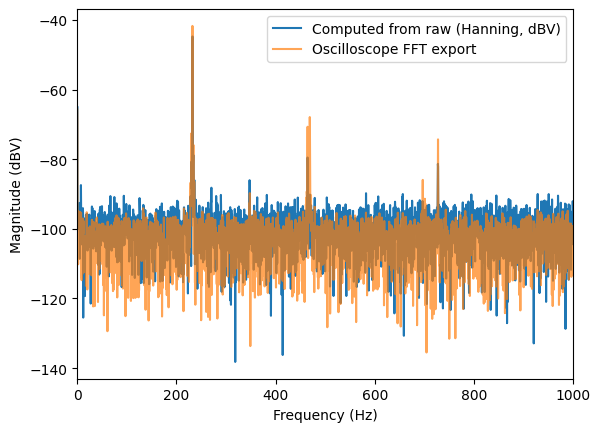

In [12]:
#SANTIY CHECK (CHECK IF GRAPHS ARE SIMILAR)

#keep in mind the oscilloscope fft used the entire timeline, while the computed fft used the trimmed timeline
#this means there should be some differences, but as long as the main peaks are in the same spots its good

center, span = 500, 1000
f_lo, f_hi = max(0, center-span/2), center+span/2

magnitude_band, freqs_band = fft_trimmed(3500)

i, j, r = 0, 0, 0 #pick one example cell to compare

osc_freq = fft_array[i, j, r, :, 0]
osc_mag = fft_array[i, j, r, :, 3]

plt.plot(freqs_band, magnitude_band[i, j, r], label="Computed from raw (Hanning, dBV)")
plt.plot(osc_freq, osc_mag, label="Oscilloscope FFT export", alpha=0.7)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dBV)")
plt.xlim(f_lo, f_hi)
plt.legend()
plt.show()

In [13]:
#CHECK DATA DIMENSIONS

def check_data_dimensions(magnitude_band):
    n_lengths = magnitude_band.shape[0]
    n_forces = magnitude_band.shape[1]
    n_samples = magnitude_band.shape[2]
    n_frequencies = magnitude_band.shape[3]

    print("Magnitude band shape:")
    print(magnitude_band.shape)

    print(f"Lengths: {n_lengths}")
    print(f"Forces: {n_forces}")
    print(f"Samples: {n_samples}")
    print(f"Frequencies: {n_frequencies}\n")

#DATA DIAGNOSTICS

def data_diagnostics(freqs_band, magnitude_band):
    print(f"frequency range: {freqs_band[0]} to {freqs_band[-1]} Hz")
    print(f"global minimum: {np.nanmin(magnitude_band)} dBV")
    print(f"global maximum: {np.nanmax(magnitude_band)} dBV\n")

In [14]:
#FIND PEAKS IN ONE INDIVIDUAL FFT

#find significant peaks in one individual FFT
#peak contribution is calculated using linear amplitude, therefore detected peaks sum to 100%
def find_peaks_in_fft(spectrum_here, freqs_band):
    spectrum_linear = 10**(spectrum_here/20) #convert dBV to linear amplitude

    mean_linear = np.mean(spectrum_linear) #calculate average background level
    mean_db = 20*np.log10(mean_linear)

    candidate_indices, _ = find_peaks(spectrum_here, distance=MIN_DISTANCE_BINS) #find local peaks

    candidate_indices = candidate_indices[freqs_band[candidate_indices] >= MIN_PEAK_FREQUENCY_HZ] #remove 0 hz disturbance

    peak_db = spectrum_here[candidate_indices]
    peak_above_mean_db = peak_db-mean_db
    significant = (peak_above_mean_db >= BACKGROUND_MARGIN_DB)
    peak_indices = candidate_indices[significant]

    peak_freqs = freqs_band[peak_indices]
    peak_db_values = spectrum_here[peak_indices]
    peak_linear = 10**(peak_db_values/20)

    peak_percent = peak_linear/np.sum(peak_linear)*100 #calculate peak contribution

    return (peak_freqs, peak_linear, peak_percent)

#MATCH PEAKS BETWEEN THE 3 SAMPLES

#match peaks from the three samples by frequency
#peaks within tolerance_hz are treated as the same physical peak
#frequency, magnitude and contribution are averaged
#contribution is reduced when the peak is found in fewer samples
def average_sample_peaks(sample_peak_data, tolerance_hz):
    all_peaks = []

    for sample_number, data in enumerate(sample_peak_data):
        for p in range(len(data[0])):
            all_peaks.append({
                "sample": sample_number,
                "frequency": data[0][p],
                "magnitude": data[1][p],
                "percent": data[2][p]
            }) #collect all peaks

    all_peaks.sort(key=lambda x: x["frequency"]) #sort by frequency

    groups = []

    for peak in all_peaks:
        for group in groups:
            group_mean_frequency = np.mean([p["frequency"] for p in group])
            if abs(peak["frequency"]-group_mean_frequency) <= tolerance_hz:
                group.append(peak) #group peaks
                break
        else:
            groups.append([peak]) #create new group

    averaged_peaks = []

    for group in groups:
        averaged_percent = np.mean([p["percent"] for p in group]) #average groups
        number_of_samples = len(set(p["sample"] for p in group))

        if SAMPLE_CONSISTENCY_WEIGHT:
            averaged_percent *= number_of_samples/magnitude_band.shape[2] #change weight in average depending on no. of samples

        averaged_peaks.append({
            "frequency": np.mean([p["frequency"] for p in group]),
            "magnitude": np.mean([p["magnitude"] for p in group]),
            "percent": averaged_percent,
            "n_samples": number_of_samples
        })

    return averaged_peaks

In [15]:
#PRINT RESULTS

def print_results():
    print(f"Found {len(averaged_results)} averaged peaks\n")
    print("Averaged peaks:\n")

    for x in averaged_results:
        print(
            f"Length = {x['length']}, "
            f"Force = {x['force']}, "
            f"Frequency = {x['frequency']:.2f} Hz, "
            f"Magnitude = {x['magnitude']:.5g} V, "
            f"Contribution = {x['percent']:.2f}%, "
            f"Samples = {x['n_samples']}/3"
        )

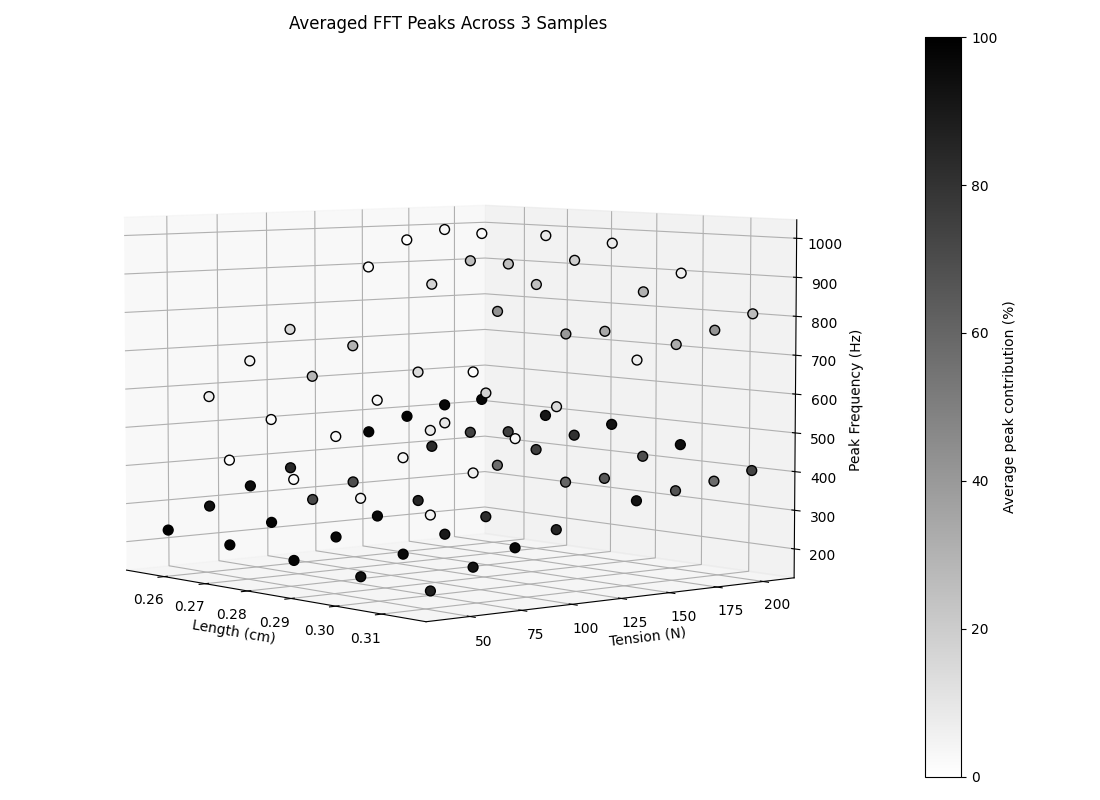

In [16]:
%matplotlib widget

#PEAK-DETECTION SETTINGS

MIN_PEAK_FREQUENCY_HZ = 2 #minimum frequency that can be considered a valid peak
BACKGROUND_MARGIN_DB = 20 #minimum height above the average level of the individual FFT
MIN_DISTANCE_BINS = 20 #minimum number of FFT bins between detected peaks
PEAK_MATCH_TOLERANCE_HZ = 10 #peaks in different samples within this frequency range will be considered the same physical peak
SAMPLE_CONSISTENCY_WEIGHT = True #weight peak contribution according to how many samples contain the peak

frequency_resolution = freqs_band[1]-freqs_band[0]

#FIND AND AVERAGE CORRESPONDING PEAKS

averaged_results = []

for i in range(magnitude_band.shape[0]):
    for j in range(magnitude_band.shape[1]):

        sample_peak_data = []

        for k in range(magnitude_band.shape[2]):
            spectrum_here = magnitude_band[i, j, k, :]
            sample_peak_data.append(find_peaks_in_fft(spectrum_here, freqs_band))

        averaged_peaks = average_sample_peaks(sample_peak_data, PEAK_MATCH_TOLERANCE_HZ)

        for peak in averaged_peaks:
            averaged_results.append({
                "length_index": i,
                "force_index": j,
                "length": length_grid[i, j],
                "force": force_grid[i, j],
                "frequency": peak["frequency"],
                "magnitude": peak["magnitude"],
                "percent": peak["percent"],
                "n_samples": peak["n_samples"]
            })

#CONVERT RESULTS TO ARRAYS

peak_lengths = np.array([x["length"] for x in averaged_results])
peak_forces = np.array([x["force"] for x in averaged_results])
peak_frequencies = np.array([x["frequency"] for x in averaged_results])
peak_magnitudes = np.array([x["magnitude"] for x in averaged_results])
peak_percent = np.array([x["percent"] for x in averaged_results])
peak_sample_count = np.array([x["n_samples"] for x in averaged_results])

#3D MATPLOTLIB PLOT

if len(averaged_results) > 0:
    fig = plt.figure(figsize=(11, 8))
    ax = fig.add_subplot(111, projection="3d")
    scatter = ax.scatter(peak_lengths, peak_forces, peak_frequencies, c=peak_percent, cmap="gray_r", vmin=0, vmax=100, s=50, edgecolors="black", depthshade=False)
    ax.set_xlabel("Length (cm)")
    ax.set_ylabel("Tension (N)")
    ax.set_zlabel("Peak Frequency (Hz)")
    ax.set_title("Averaged FFT Peaks Across 3 Samples")
    ax.view_init(elev=5, azim=-40)
    cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
    cbar.set_label("Average peak contribution (%)")
    plt.tight_layout()
    plt.show()

In [17]:
#SEPARATE HARMONICS

harmonic_ratio_tolerance = 0.15 #allowed fractional deviation from exactly 2x

cells = defaultdict(list)
for k in range(len(averaged_results)):
    key = (averaged_results[k]["length_index"], averaged_results[k]["force_index"])
    cells[key].append(k)

fundamental_rows = []
harmonic_rows = []
third_harmonic_rows = []

for key, indices in cells.items():
    indices_sorted = sorted(indices, key=lambda k: peak_frequencies[k])
    freqs_here = peak_frequencies[indices_sorted]

    f1 = freqs_here[0]
    fundamental_rows.append(indices_sorted[0])

    for idx, f in zip(indices_sorted[1:], freqs_here[1:]):
        if abs(f-2*f1)/(2*f1) <= harmonic_ratio_tolerance:
            harmonic_rows.append(idx)
        elif abs(f - 3 * f1) / (3 * f1) <= harmonic_ratio_tolerance:
            third_harmonic_rows.append(idx)
            # break

print(f"Found {len(fundamental_rows)} fundamentals, {len(harmonic_rows)} confirmed first harmonics, {len(third_harmonic_rows)} 3rd harmonics")

fundamental_lengths = peak_lengths[fundamental_rows]
fundamental_forces = peak_forces[fundamental_rows]
fundamental_frequencies = peak_frequencies[fundamental_rows]

harmonic_lengths = peak_lengths[harmonic_rows]
harmonic_forces = peak_forces[harmonic_rows]
harmonic_frequencies = peak_frequencies[harmonic_rows]

third_harmonic_lengths = peak_lengths[third_harmonic_rows]
third_harmonic_forces = peak_forces[third_harmonic_rows]
third_harmonic_frequencies = peak_frequencies[third_harmonic_rows]

Found 40 fundamentals, 39 confirmed first harmonics, 2 3rd harmonics


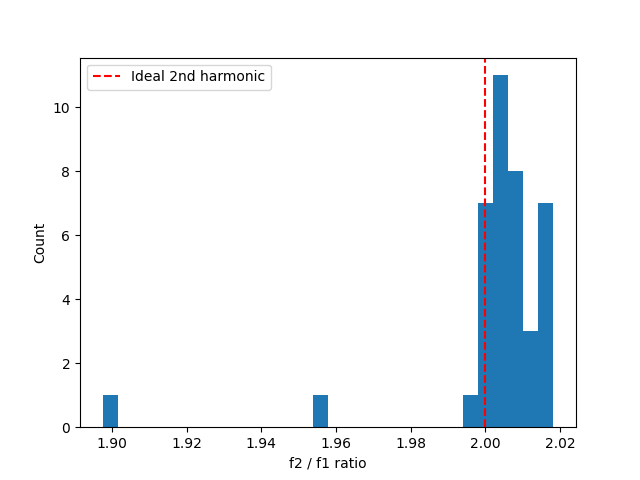

In [18]:
ratios = []
for key, indices in cells.items():
    indices_sorted = sorted(indices, key=lambda k: peak_frequencies[k])
    freqs_here = peak_frequencies[indices_sorted]
    if len(freqs_here) >= 2:
        ratios.append(freqs_here[1]/freqs_here[0])

plt.figure()
plt.hist(ratios, bins=30)
plt.axvline(2.0, color="red", linestyle="--", label="Ideal 2nd harmonic")
plt.xlabel("f2 / f1 ratio")
plt.ylabel("Count")
plt.legend()
plt.show()

In [19]:
def combined_model(LF_and_mode, mu):
    L, F, mode_number = LF_and_mode
    return (mode_number/(2*L))*np.sqrt(F/mu)

L_all = np.concatenate([fundamental_lengths, harmonic_lengths, third_harmonic_lengths])
F_all = np.concatenate([fundamental_forces, harmonic_forces, third_harmonic_forces])
mode_all = np.concatenate([np.ones_like(fundamental_lengths), np.full_like(harmonic_lengths, 2), np.full_like(third_harmonic_lengths, 3)])
freq_all = np.concatenate([fundamental_frequencies, harmonic_frequencies, third_harmonic_frequencies])

popt, pcov = curve_fit(combined_model, (L_all, F_all, mode_all), freq_all, p0=[0.001])
mu_fit = popt[0]
mu_uncertainty = np.sqrt(pcov[0, 0])
print(f"Fitted linear mass density: {mu_fit:.6g} ± {mu_uncertainty:.2g} kg/m")

Fitted linear mass density: 0.00288515 ± 1.9e-05 kg/m


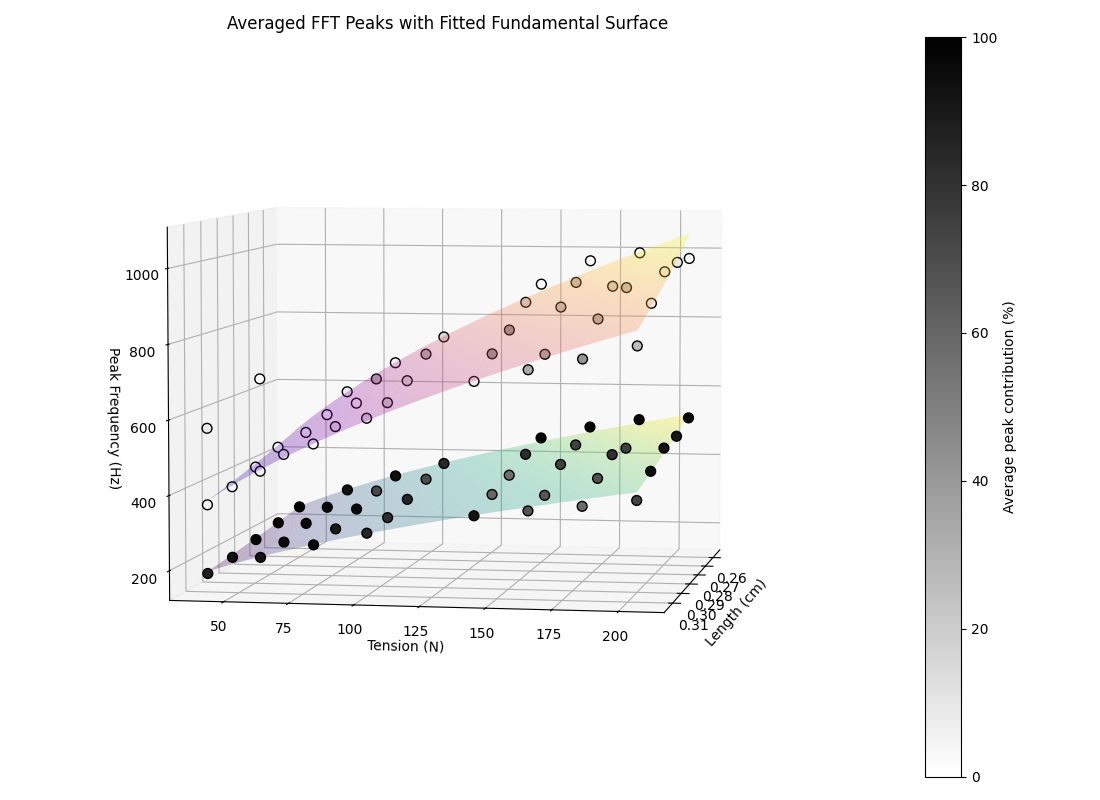

In [20]:
#3D MATPLOTLIB PLOT WITH FITTED SURFACE

#build a grid spanning the data's length/force range, in the same units as peak_lengths/peak_forces
L_grid = np.linspace(peak_lengths.min(), peak_lengths.max(), 40)
F_grid = np.linspace(peak_forces.min(), peak_forces.max(), 40)
L_mesh, F_mesh = np.meshgrid(L_grid, F_grid)

freq_surface = combined_model((L_mesh, F_mesh, 1), mu_fit) #mode_number=1: fundamental
freq_surface_harmonic = combined_model((L_mesh, F_mesh, 2), mu_fit) #mode_number=2: first harmonic

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")
scatter = ax.scatter(peak_lengths, peak_forces, peak_frequencies, c=peak_percent, cmap="gray_r", vmin=0, vmax=100, s=50, edgecolors="black", depthshade=False)
ax.plot_surface(L_mesh, F_mesh, freq_surface, alpha=0.3, cmap="viridis", edgecolor="none")
ax.plot_surface(L_mesh, F_mesh, freq_surface_harmonic, alpha=0.3, cmap="plasma", edgecolor="none")
ax.set_xlabel("Length (cm)")
ax.set_ylabel("Tension (N)")
ax.set_zlabel("Peak Frequency (Hz)")
ax.set_title("Averaged FFT Peaks with Fitted Fundamental Surface")
ax.view_init(elev=5, azim=10)
cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label("Average peak contribution (%)")
plt.tight_layout()
plt.show()

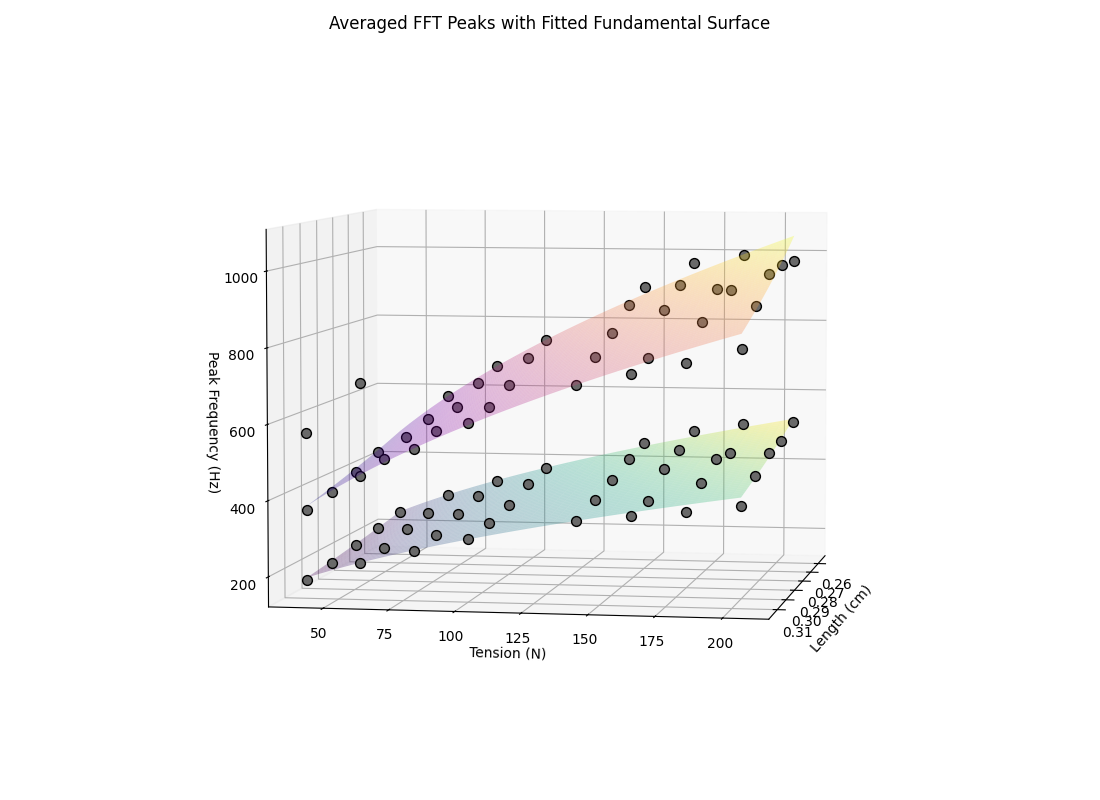

In [21]:
fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")
scatter = ax.scatter(peak_lengths, peak_forces, peak_frequencies, color="dimgray", s=50, edgecolors="black", depthshade=False)
ax.plot_surface(L_mesh, F_mesh, freq_surface, alpha=0.3, cmap="viridis", edgecolor="none")
ax.plot_surface(L_mesh, F_mesh, freq_surface_harmonic, alpha=0.3, cmap="plasma", edgecolor="none")
ax.set_xlabel("Length (cm)")
ax.set_ylabel("Tension (N)")
ax.set_zlabel("Peak Frequency (Hz)")
ax.set_title("Averaged FFT Peaks with Fitted Fundamental Surface")
ax.view_init(elev=5, azim=10)
plt.tight_layout()
plt.show()

In [22]:
rho_stainless = 7900  # kg/m^3, typical stainless steel density

def diameter_from_mu(mu, rho):
    area = mu/rho
    diameter = 2*np.sqrt(area/np.pi)
    return diameter

d = diameter_from_mu(mu_fit, rho_stainless)

# propagate mu's relative uncertainty through the sqrt relationship
relative_mu_unc = mu_uncertainty/mu_fit
d_unc = d*0.5*relative_mu_unc

print(f"Implied wire diameter: {d*1000:.4f} ± {d_unc*1000:.4f} mm")

Implied wire diameter: 0.6819 ± 0.0022 mm


In [ ]:
known_diameter_mm, known_diameter_unc_mm = 1.0, 0.1

d_m = known_diameter_mm/1000
area = np.pi*(d_m/2)**2
mu_expected = rho_stainless*area

relative_d_unc = known_diameter_unc_mm/known_diameter_mm
mu_expected_unc = mu_expected*2*relative_d_unc

print(f"Expected μ from known diameter: {mu_expected:.6g} ± {mu_expected_unc:.2g} kg/m")
print(f"μ (fitted) = {mu_fit:.6g} ± {mu_uncertainty:.2g} kg/m")

Expected μ from known diameter: 0.00620465 ± 0.00012 kg/m
μ (fitted) = 0.00288515 ± 1.9e-05 kg/m


In [24]:
lower_fit, upper_fit = mu_fit - mu_uncertainty, mu_fit + mu_uncertainty
lower_exp, upper_exp = mu_expected - mu_expected_unc, mu_expected + mu_expected_unc

overlap = (lower_fit <= upper_exp) and (lower_exp <= upper_fit)
print(f"Fitted and expected μ {'agree' if overlap else 'do NOT agree'} within uncertainty")

Fitted and expected μ do NOT agree within uncertainty
